<a href="https://colab.research.google.com/github/yusuffenes/transformers_model/blob/main/Sentiment_Analysis_TR_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load data and import libaries

In [1]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import to_categorical
from keras import layers, models
from keras.preprocessing.sequence import pad_sequences


In [3]:
from datasets import load_dataset

ds = load_dataset("winvoker/turkish-sentiment-analysis-dataset")
ds

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.99k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/76.1M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/8.47M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/440679 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/48965 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'dataset'],
        num_rows: 440679
    })
    test: Dataset({
        features: ['text', 'label', 'dataset'],
        num_rows: 48965
    })
})

In [4]:
train_data = pd.DataFrame(ds['train'])
test_data = pd.DataFrame(ds['test'])

X_train ,y_train= train_data['text'], train_data['label']
X_test ,y_test= test_data['text'], test_data['label']


In [75]:
nltk.download('stopwords')
stop_words = set(stopwords.words('turkish'))

def remove_stopwords(text):
    kelimeler = text.split()
    temiz_kelimeler = [kelime for kelime in kelimeler if kelime.lower() not in stop_words]
    return ' '.join(temiz_kelimeler)

X_train_clean = X_train.apply(remove_stopwords)
X_test_clean = X_test.apply(remove_stopwords)


tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_clean)


X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)


sequence_lengths = [len(seq) for seq in X_train_seq]
max_length = int(np.percentile(sequence_lengths, 98))


X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

X_train_padded.shape

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


(440679, 77)

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [6]:
word_index = tokenizer.word_index
reverse_word_index = {value: key for key, value in word_index.items()}
reverse_word_index[0] = '<PAD>'


def sequence_to_text(sequence):
    return ' '.join([reverse_word_index.get(i, '<UNK>') for i in sequence])



print(X_test_padded[12])
print(sequence_to_text(X_test_padded[12]))

[  112     3    33    95    48    36   145  1127   345   275 86986  9532
  2074  3286   351 10349  2393  2001  1995  5722  1051  4168   136   906
     9     4    33  4030     1   569  1297     2   538  7671    10  2350
  9438  2335    11     3 25679  1028   159  1777     1    15 52468    10
  1986  1742    22   262    67   566     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0]
arkadaşlar ürün 1 saat önce elime geçti hayran oldum öncelikle whatsapptan kulaklıkla arama yapabiliyorsunuz müzik dinleme seçeneği konuşma derken eliniz telefona gitmiyor pek tasarım olarak iyi 1 anahtar <OOV> rengi tatlı bir siyah gördüğünüz kadar gri detaylar felan yok ürün genpa garantili geliyor kutusunda <OOV> var diyeceklerim kadar öneriyorum parasına göre düşünmeden 5 yıldız <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>


In [30]:
# transformers

class TransformerBlock(layers.Layer):

  def __init__(self, embed_size, heads, dropout=0.3):
    super(TransformerBlock, self).__init__()

    self.attention = layers.MultiHeadAttention(num_heads=heads,key_dim=embed_size)
    self.norm1 = layers.LayerNormalization(epsilon=1e-6)  # Normalizasyon katmanı
    self.norm2 = layers.LayerNormalization(epsilon=1e-6)

    self.feed_forward = models.Sequential(
        [
            layers.Dense(embed_size*4,activation = 'relu'),
            layers.Dense(embed_size)
        ]
    )

    self.dropout1 = layers.Dropout(dropout)
    self.dropout2 = layers.Dropout(dropout)

  def call(self, x , training):
     # attention aplly

     attention = self.attention(x,x)
     x = self.norm1(x + self.dropout1(attention,training = training))
     feed_forward = self.feed_forward(x)
     return self.norm2(x+ self.dropout2(feed_forward,training = training))




In [31]:
class TransformerModel(models.Model):
  def __init__(self, num_layers, embed_size, heads, input_dim, output_dim, dropout_rate = 0.1):
    super(TransformerModel,self).__init__()

    self.embedding = layers.Embedding(input_dim = input_dim,output_dim=embed_size)
    self.transformer_blocks = [TransformerBlock(embed_size,heads,dropout_rate) for _ in range(num_layers)]
    self.global_avg_pooling = layers.GlobalAveragePooling1D()
    self.dropout = layers.Dropout(dropout_rate)
    self.fc = layers.Dense(output_dim,activation='softmax')

  def call(self,x,training):
    x = self.embedding(x)
    for transformer in self.transformer_blocks:
      x = transformer(x,  training=training)
    x = self.global_avg_pooling(x)
    x = self.dropout(x,training = training)

    return self.fc(x)




model Training


In [32]:
max_features = min(20000, len(word_index) + 1)

num_layers = 4
embed_size = 128
num_heads = 4
input_dim = max_features
output_dim = 3
dropout_rate= 0.1

model = TransformerModel(num_layers, embed_size, num_heads,input_dim, output_dim,dropout_rate)


model.build(input_shape = (None,max_length))

model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'transformer_model_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "transformer_model_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_12            │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_13            │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_14            │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_15            │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

model fit

In [33]:
history = model.fit(X_train_padded,y_train,epochs=5,batch_size=256,validation_data=(X_test_padded,y_test))

Epoch 1/5
1722/1722 ━━━━━━━━━━━━━━━━━━━━ 280s 149ms/step - accuracy: 0.7856 - loss: 0.5210 - val_accuracy: 0.9375 - val_loss: 0.1710
Epoch 2/5
1722/1722 ━━━━━━━━━━━━━━━━━━━━ 296s 141ms/step - accuracy: 0.9439 - loss: 0.1552 - val_accuracy: 0.9369 - val_loss: 0.1786
Epoch 3/5
1722/1722 ━━━━━━━━━━━━━━━━━━━━ 261s 141ms/step - accuracy: 0.9477 - loss: 0.1457 - val_accuracy: 0.9351 - val_loss: 0.1823
Epoch 4/5
1722/1722 ━━━━━━━━━━━━━━━━━━━━ 261s 140ms/step - accuracy: 0.9476 - loss: 0.1449 - val_accuracy: 0.9298 - val_loss: 0.2000
Epoch 5/5
1722/1722 ━━━━━━━━━━━━━━━━━━━━ 265s 142ms/step - accuracy: 0.9451 - loss: 0.1541 - val_accuracy: 0.9332 - val_loss: 0.1904


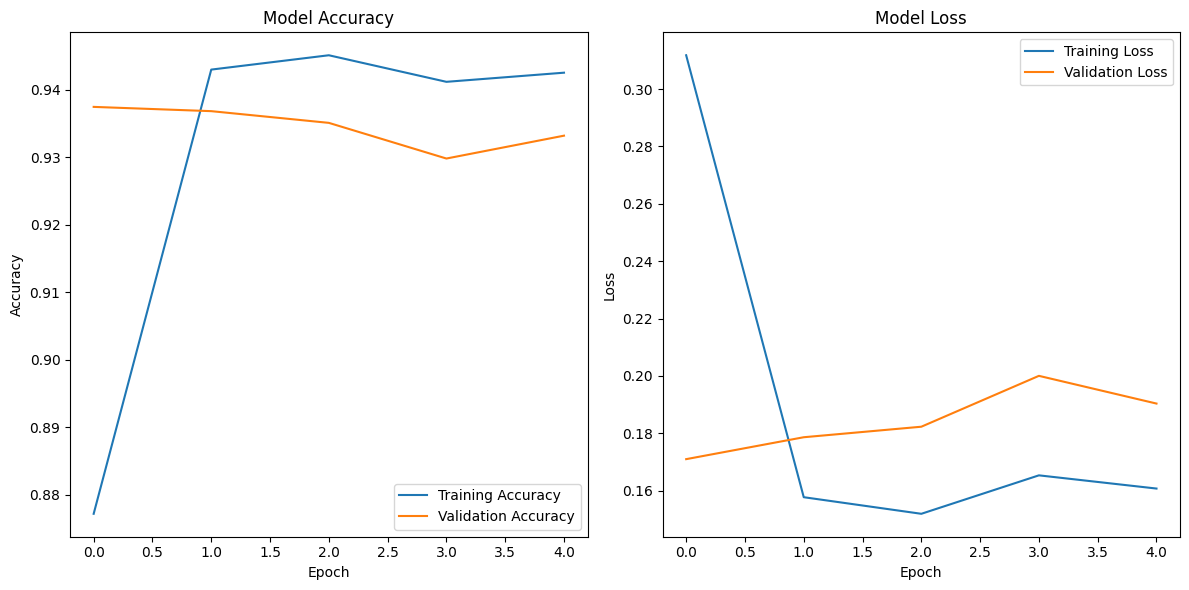

In [34]:
plt.figure(figsize=(12, 6))

# Doğruluk grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Kayıp grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [79]:
def predict_sentiment(text, tokenizer, model, max_len):
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=max_len, padding='post')

    prediction = model.predict(padded)[0]  # Tek bir örnek olduğundan [0] ile düzleştiriyoruz
    class_index = np.argmax(prediction)    # En yüksek olasılıklı sınıfın indexini al


    class_labels = {0: "negatif", 1: "nötr", 2: "pozitif"}
    predicted_label = class_labels[class_index]

    confidence = prediction[class_index]
    print(f"Yanlış Oranı: {prediction[0]:.4f} - Nötr Oranı: {prediction[1]:.4f} - Doğru Oranı: {prediction[2]:.4f}")
    return f"Tahmin: {predicted_label} ({confidence:.2f} güven)"

text = """
Yeni gelen güncelleme sayesinde arayüz çok daha modern görünüyor ama kullanım kolaylığı tamamen gitmiş. Bir şeyleri bulmak daha zor artık. Görsellik uğruna işlevsellikten vazgeçilmiş gibi.
"""
result = predict_sentiment(model = model, tokenizer = tokenizer, text = text, max_len = X_train_padded.shape[1])

print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Yanlış Oranı: 0.2036 - Nötr Oranı: 0.0011 - Doğru Oranı: 0.7952
Tahmin: pozitif (0.80 güven)


In [74]:
model.save("transformers_sentiment_model_400kdata.h5")